# Spectrograph: Dispersion resolution vs. spotsize

The dispersion resolution is associated to the resolving power "R". The spotsize corresponds to the footprint of a monochromatic pointsource on the detector in pixels. 
Of course, the dispersion resolution is connected to the spotsize, a large spotsize corresponds to an increased dispersion resolution.

The expected (Nyquist limit) dispersion resolution is 2 (see, advanced_change_resolution_dispersion). 

In practice, one may want to :
1. either, change dispersion resolution without changing the resolving power, resulting into a change in wavelength binning.
2. or, change the dispersion resolution while conserving the same wavelength binning, resulting into a change in resolving power.

The second case would for instance corresponds to a predined optical system whose aberation changes, changing the "spotsize", which results into a change of resolving power but not a change on how the light is dispersed and thus where the wavelength binning is.

In `slicersim`, `Spectrograph` consequently allows two `mutable_parameters`: `dispersion_resolution` and `spotsize`.
- updating any of these would change `self.dispersion_resolution` which captures into how many pixel light is dispersed to (like spotsize)
- *but* changing `spotsize` would *not* redraw `self.lbda` while changing `dispersion_resolution` would.

**In any case**, since `self.dispersion_resolution` is updated, the inpact of the instrumental psf on the spatial direction (slicer) or x-dispersion (mla) will be updated.


Finally, the `dispersion_scale` parameter enables the user to change the amplitude of the resolution_power without changing the `dispersion_resolution` (hence not the `spotsize`).

## Illustration

In [1]:
import slicersim
# loading a star at mag 20 assuming the bd_17 spectra.
bd17 = slicersim.LazuliCalSpec.from_name("bd_17", mag=20)
spectro = bd17.simulation.spectrograph

Let's see the current minimal resolving power (R)

In [2]:
resolving_power = spectro.get_resolving_power().copy() # copy to compare later on
resolving_power.min()

np.float64(125.35501478621651)

and the corresponding resolution_dispersion

In [3]:
spectro.dispersion_resolution

2

In [4]:
lbda, flux, var = bd17.get_spectrum("flambda", incl_error=False)

/Users/rigault/miniforge3/envs/pearl/lib/python3.11/site-packages/slicersim/simulation.py:1490: RuntimeWarning: divide by zero encountered in divide
  coefs = 1 / (transmission * self.get_parameter("nramps"))


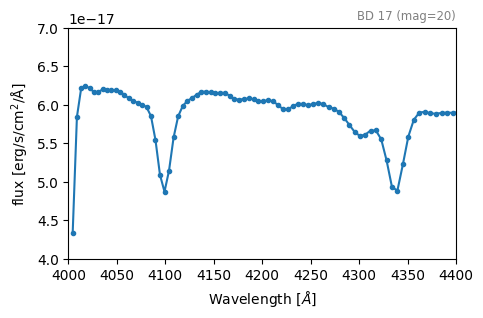

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(lbda, flux, marker=".")

#ax.set_xscale("log")
ax.set_xlim(4000, 4400)
ax.set_ylim(4e-17, 7e-17)
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"flux [$\mathrm{erg/s/cm^2/\AA}$]")
ax.set_title("BD 17 (mag=20)", loc="right", color="0.5", fontsize="small");


### Changing the spotsize

In [6]:
what_has_changed = spectro.update(spotsize=2.5)

In [7]:
# Now let's see how the resolving_power has changed.
resolving_power_sp25 = spectro.get_resolving_power().copy()
resolving_power_sp25.min()

np.float64(100.2840118289732)

In [8]:
# Get the new spectrum.
lbda_sp25, flux_sp25, var_sp25 = bd17.get_spectrum("flambda", incl_error=False)

/Users/rigault/miniforge3/envs/pearl/lib/python3.11/site-packages/slicersim/simulation.py:1490: RuntimeWarning: divide by zero encountered in divide
  coefs = 1 / (transmission * self.get_parameter("nramps"))


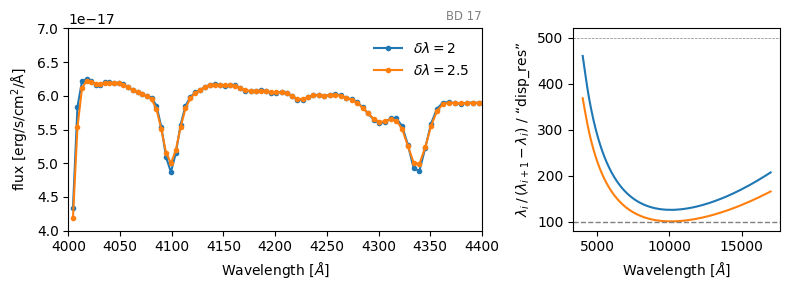

In [9]:
fig, (ax, axres) = plt.subplots(figsize=(8,3), ncols=2, width_ratios=(2,1))

# Compare the spectra
ax.plot(lbda, flux, marker=".", label=r"$\delta \lambda = 2$")
ax.plot(lbda_sp25, flux_sp25, marker=".", label=r"$\delta \lambda = 2.5$")
ax.legend(frameon=False)
#ax.set_xscale("log")
ax.set_xlim(4000, 4400)
ax.set_ylim(4e-17, 7e-17)
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"flux [$\mathrm{erg/s/cm^2/\AA}$]")
ax.set_title("BD 17", loc="right", color="0.5", fontsize="small")


# and the resolving power

axres.plot(lbda, resolving_power)
axres.plot(lbda_sp25, resolving_power_sp25)
axres.axhline(100, ls="--", color="0.5", lw=1)
axres.axhline(500, ls="--", color="0.5", lw=0.5)
axres.set_xlabel(r"Wavelength [$\AA$]")
axres.set_ylabel(r"$\lambda_i\,/ \, \left(\lambda_{i+1} - \lambda_i\right)$ / “disp_res”")

fig.tight_layout()
fig.savefig("/Users/rigault/data/plot/lazuli/dispersion_resolution_lsf.pdf")

In that case, since we changed `spotsize` the wavelengths have not changed.

In [10]:
import numpy as np
np.isclose(lbda_sp25, lbda).all()

np.True_

## Changing the dispersion_resolution

This will change self.lbda to conserve the original resolving_power of >=125. Consequently, we will have more lbda bins

In [11]:
what_has_changed = spectro.update(dispersion_resolution=2.5)
what_has_changed

['lbda', 'meta']

In [12]:
spectro.lbda.shape

(711,)

In [13]:
# Now let's see how the resolving_power has changed.
resolving_power_res25 = spectro.get_resolving_power().copy()
resolving_power_res25.min()

np.float64(125.3548191894776)

In [14]:
# Get the new spectrum.
lbda_res25, flux_res25, var_res25 = bd17.get_spectrum("flambda", incl_error=False)

/Users/rigault/miniforge3/envs/pearl/lib/python3.11/site-packages/slicersim/simulation.py:1490: RuntimeWarning: divide by zero encountered in divide
  coefs = 1 / (transmission * self.get_parameter("nramps"))


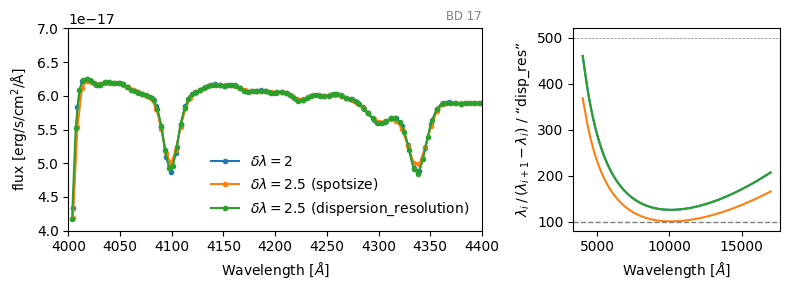

In [15]:
fig, (ax, axres) = plt.subplots(figsize=(8,3), ncols=2, width_ratios=(2,1))

# Compare the spectra
ax.plot(lbda, flux, marker=".", label=r"$\delta \lambda = 2$")
ax.plot(lbda_sp25, flux_sp25, marker=".", label=r"$\delta \lambda = 2.5$ (spotsize)")
ax.plot(lbda_res25, flux_res25, marker=".", label=r"$\delta \lambda = 2.5$ (dispersion_resolution)")

ax.legend(frameon=False)
#ax.set_xscale("log")
ax.set_xlim(4000, 4400)
ax.set_ylim(4e-17, 7e-17)
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"flux [$\mathrm{erg/s/cm^2/\AA}$]")
ax.set_title("BD 17", loc="right", color="0.5", fontsize="small")

# and the resolving power
axres.plot(lbda, resolving_power)
axres.plot(lbda_sp25, resolving_power_sp25)
axres.plot(lbda_res25, resolving_power_res25)

axres.axhline(100, ls="--", color="0.5", lw=1)
axres.axhline(500, ls="--", color="0.5", lw=0.5)
axres.set_xlabel(r"Wavelength [$\AA$]")
axres.set_ylabel(r"$\lambda_i\,/ \, \left(\lambda_{i+1} - \lambda_i\right)$ / “disp_res”")

fig.tight_layout()
fig.savefig("/Users/rigault/data/plot/lazuli/dispersion_resolution_lsf.pdf")

## Scaling the resolusion_power using `dispersion_scale`

Finally, one may want to change the resolution power without changing the resolution_dispersion (so not the "spotsize").

You can do so by updating the "dispersion_scale". 

In [16]:
import slicersim
# loading a star at mag 20 assuming the bd_17 spectra.
bd17 = slicersim.LazuliCalSpec.from_name("bd_17", mag=20)
spectro = bd17.simulation.spectrograph

In [17]:
_ = spectro.update(dispersion_scale=1.3)

In [18]:
spectro.get_resolving_power().min()

np.float64(100.59530595996385)

In [19]:
spectro.lbda.shape

(457,)

## Combaning `dispersion_scale`, `dispersion_resolution` and `spotsize`

As a consequence of the aforementioned design, one can redefine the resolution_power for any assumed dispersion_resolution by updating both simultaneously.

for instance, using a scale of 1.3 (leading to a minimal resolution_power of 100) for a dispersion_resolution of 2.5

(Note: 1.3 => R>=100)

In [32]:
_ = spectro.update(dispersion_scale=1.3, dispersion_resolution=2.5)
new_lbda = spectro.lbda.copy() # store for later comparison

In [33]:
spectro.get_resolving_power().min()

np.float64(100.5938757751203)

If we are now to have a better than planed spectrograph, hence having a better than 2.5 spotsize, the resolution_power increases

In [28]:
_ = spectro.update(spotsize=2)

In [29]:
spectro.get_resolving_power().min()

np.float64(125.74234471890037)

but lbda is unchanged

In [31]:
np.isclose(spectro.lbda,new_lbda).all()

np.True_